In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hour = pd.read_csv("hour.csv")
day = pd.read_csv("day.csv")

In [3]:
hour = hour.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
day = day.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
print("Hour dataset after dropping columns:")
print(hour.head().to_string(index=False))

print("\nDay dataset after dropping columns:")
print(day.head().to_string(index=False))


Hour dataset after dropping columns:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1

Day dataset after dropping columns:
 season  mnth  holiday  weekday  workingday  weathersit     temp    atemp      hum  windspeed  cnt
      1     1        0        6           0           2 0.344167 0.363625 0.805833   0.160446  985
      1     1        0        0           0           2 0.363478 0.353739 0.696087   0.248539  801
      1     1        0        1           1           1 0.196364 

In [4]:
hour.isnull().sum()



season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [5]:
day.isnull().sum()

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [6]:
hour_duplicates = hour.duplicated().sum()
day_duplicates = day.duplicated().sum()
print("Number of duplicate hours:", hour_duplicates)
print("Number of duplicate days:", day_duplicates)




Number of duplicate hours: 2
Number of duplicate days: 0


In [7]:
hour = hour.drop_duplicates() 
print("Hour dataset after dropping duplicates:")
print(hour.head().to_string(index=False))


Hour dataset after dropping duplicates:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1


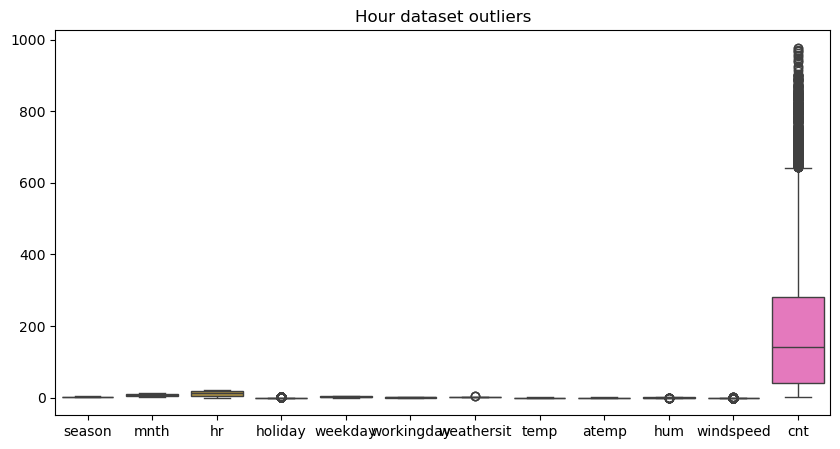

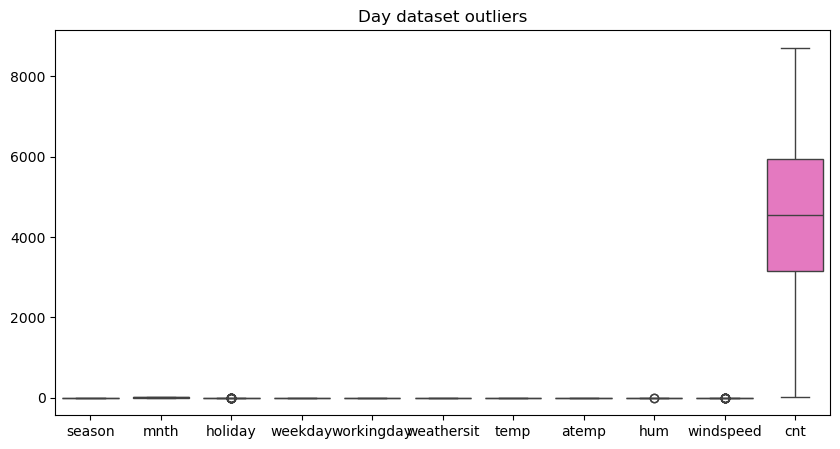

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(data=hour)
plt.title("Hour dataset outliers")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=day)
plt.title("Day dataset outliers")
plt.show()


In [9]:
# ---- Outlier Detection for Hour Data ----
Q1_hr = hour.quantile(0.25)
Q3_hr = hour.quantile(0.75)
IQR_hr = Q3_hr - Q1_hr

lower_limit_hr = Q1_hr - 1.5 * IQR_hr
upper_limit_hr = Q3_hr + 1.5 * IQR_hr

hour_cleaned = hour[~((hour < lower_limit_hr) | (hour > upper_limit_hr)).any(axis=1)]

print("Original Hour Shape:", hour.shape)
print("After Removing Outliers:", hour_cleaned.shape)

Original Hour Shape: (17377, 12)
After Removing Outliers: (16027, 12)


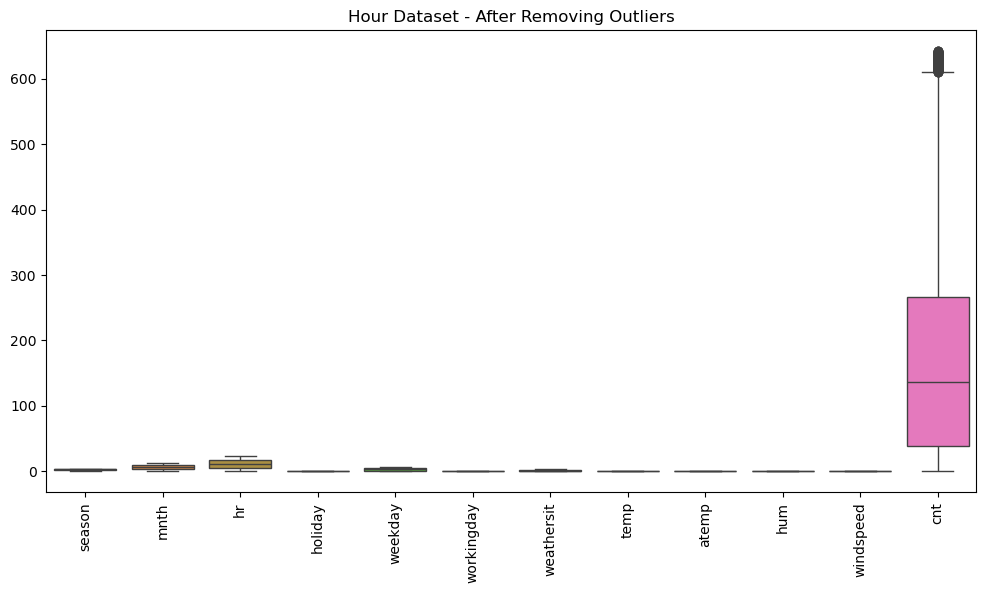

In [10]:
# ---- Boxplot after removing outliers ----
plt.figure(figsize=(12,6))
sns.boxplot(data=hour_cleaned)
plt.title("Hour Dataset - After Removing Outliers")
plt.xticks(rotation=90)
plt.show()

In [19]:
# ---- Outlier Detection for Day Data ----
Q1 = day.quantile(0.25)
Q3 = day.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

day_cleaned = day[~((day < lower_limit) | (day > upper_limit)).any(axis=1)]
print("Original Day Shape:", day.shape)
print("After Removing Outliers:", day_cleaned.shape)



Original Day Shape: (731, 11)
After Removing Outliers: (696, 11)


In [20]:
X_hour = hour.drop("cnt", axis=1)
y_hour = hour["cnt"]

X_day = day.drop("cnt", axis=1)
y_day = day["cnt"]

In [21]:
from sklearn.model_selection import train_test_split

# Hourly data train-test split
X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(X_hour, y_hour, test_size=0.2, random_state=42)
# Daily data train-test split
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)

In [22]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_evaluate_rf(X_train, X_test, y_train, y_test, dataset_name="Dataset"):
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predict
    y_pred = rf.predict(X_test)
    
    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
     
    print(f"{dataset_name} - Random Forest Metrics")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")
    return rf 
    


In [23]:
#Train & evaluate for both datasets
rf_hour = train_evaluate_rf(X_train_hr, X_test_hr, y_train_hr, y_test_hr, "Hourly Data")
rf_day  = train_evaluate_rf(X_train_day, X_test_day, y_train_day, y_test_day, "Daily Data")


Hourly Data - Random Forest Metrics
MAE: 42.88, RMSE: 64.90, R²: 0.86

Daily Data - Random Forest Metrics
MAE: 1083.93, RMSE: 1305.34, R²: 0.58



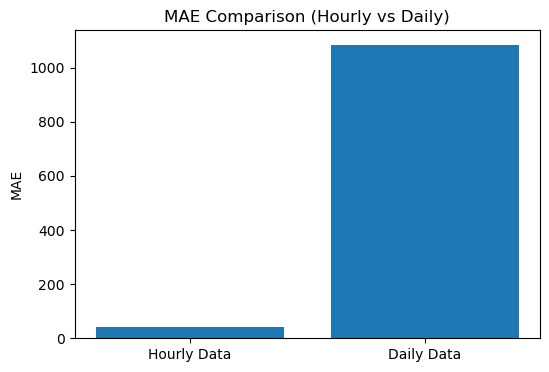

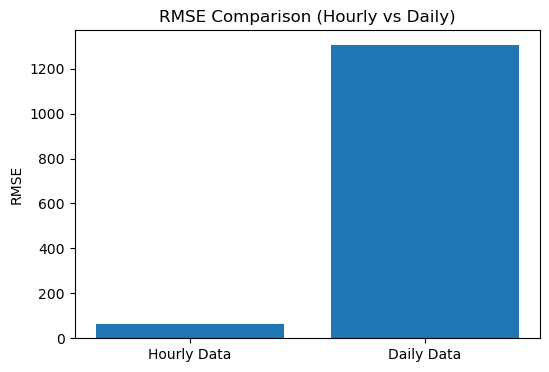

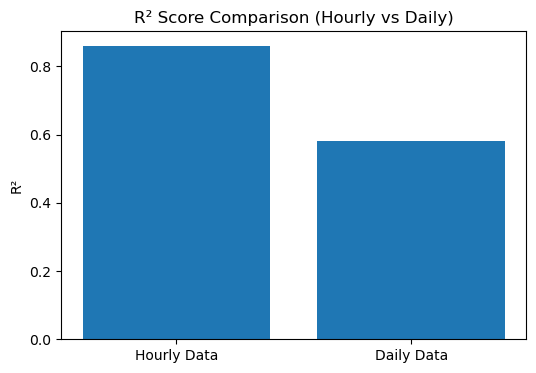

In [24]:
# ---- Metrics Comparison Graphs ----

import matplotlib.pyplot as plt

datasets = ["Hourly Data", "Daily Data"]
mae_values = [42.88, 1083.93]
rmse_values = [64.90, 1305.34]
r2_values = [0.86, 0.58]


# MAE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, mae_values)
plt.title("MAE Comparison (Hourly vs Daily)")
plt.ylabel("MAE")
plt.show()

# RMSE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, rmse_values)
plt.title("RMSE Comparison (Hourly vs Daily)")
plt.ylabel("RMSE")
plt.show()

# R² Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, r2_values)
plt.title("R² Score Comparison (Hourly vs Daily)")
plt.ylabel("R²")
plt.show()


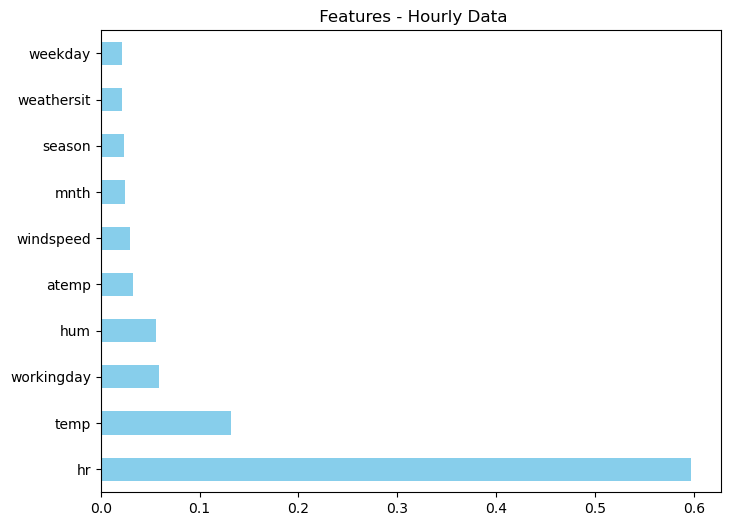

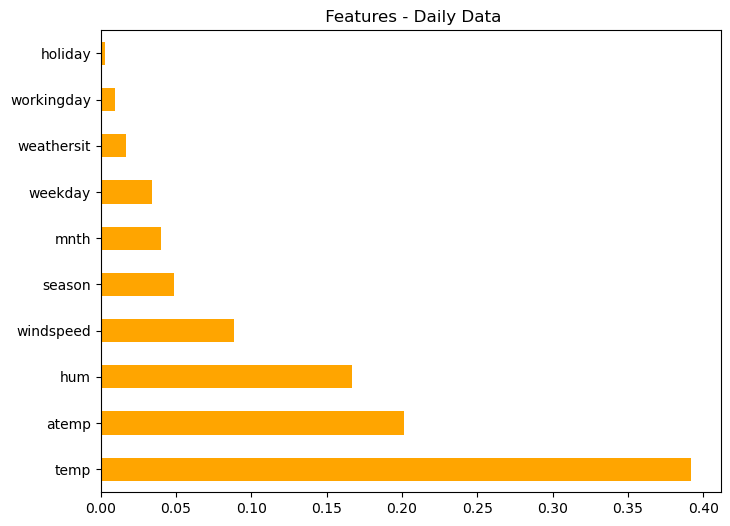

In [25]:
               # --- Feature Importance Plot ---
def plot_feature_importance(rf_model, X_train, dataset_name):
    feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    plt.figure(figsize=(8,6))
    color = 'skyblue' if dataset_name=="Hourly Data" else 'orange'
    feat_importances.nlargest(10).plot(kind='barh', color=color)
    plt.title(f" Features - {dataset_name}")
    plt.show()

# Plot top 10 features for both datasets
plot_feature_importance(rf_hour, X_train_hr, "Hourly Data")
plot_feature_importance(rf_day, X_train_day, "Daily Data")

In [26]:
# Check for nulls
print("Null values per column (Hourly):")
print(hour.isnull().sum())

print("\nNull values per column (Daily):")
print(day.isnull().sum())

# If any null values found, fill them
hour = hour.fillna(hour.median())
day = day.fillna(day.median())

print("After filling, nulls (Hourly):", hour.isnull().sum().sum())
print("After filling, nulls (Daily):", day.isnull().sum().sum())


Null values per column (Hourly):
season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Null values per column (Daily):
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
After filling, nulls (Hourly): 0
After filling, nulls (Daily): 0


In [35]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [36]:
def train_models_store(X_train, X_test, y_train, y_test):
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42)
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        results.append([
            name,
            mean_absolute_error(y_test, pred),
            np.sqrt(mean_squared_error(y_test, pred)),
            r2_score(y_test, pred)
        ])

    return pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])


In [38]:

hour_results = train_models_store(X_train_hr, X_test_hr, y_train_hr, y_test_hr)
day_results  = train_models_store(X_train_day, X_test_day, y_train_day, y_test_day)

print("Hourly Results")
print(hour_results)

print("\nDaily Results")
print(day_results)


Hourly Results
               Model         MAE        RMSE        R2
0  Linear Regression  105.720617  141.696994  0.345995
1      Decision Tree   53.935270   88.585113  0.744388
2      Random Forest   42.876734   64.900524  0.862799

Daily Results
               Model          MAE         RMSE        R2
0  Linear Regression  1143.393718  1340.514122  0.551863
1      Decision Tree  1248.163265  1644.848392  0.325285
2      Random Forest  1083.931088  1305.338730  0.575073


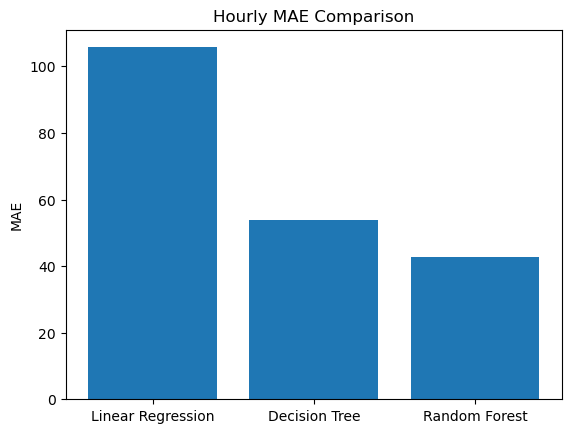

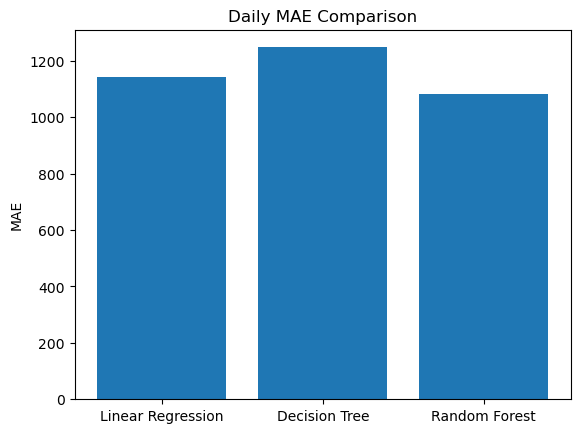

In [47]:
plt.figure()
plt.bar(hour_results["Model"], hour_results["MAE"])
plt.title("Hourly MAE Comparison")
plt.ylabel("MAE")
plt.show()

plt.figure()
plt.bar(day_results["Model"], day_results["MAE"])
plt.title("Daily MAE Comparison")
plt.ylabel("MAE")
plt.show()


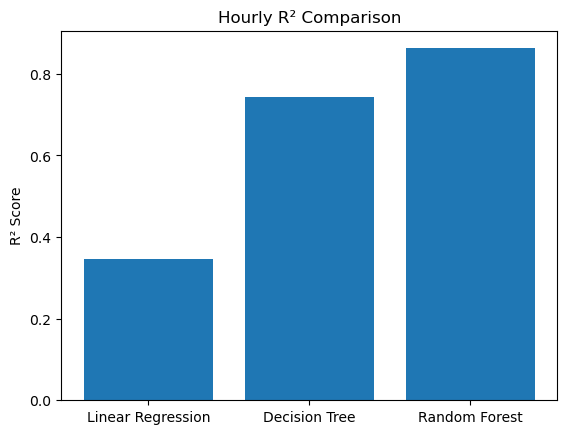

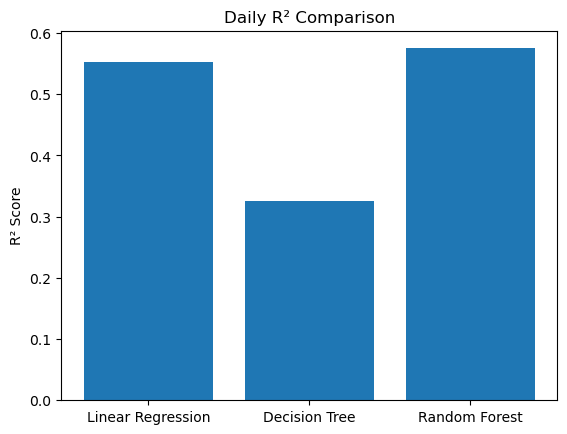

In [48]:
plt.figure()
plt.bar(hour_results["Model"], hour_results["R2"])
plt.title("Hourly R² Comparison")
plt.ylabel("R² Score")
plt.show()

plt.figure()
plt.bar(day_results["Model"], day_results["R2"])
plt.title("Daily R² Comparison")
plt.ylabel("R² Score")
plt.show()


In [61]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}


In [62]:

# Hourly Grid Search
grid_hr = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_hr.fit(X_train_hr, y_train_hr)

best_rf_hr = grid_hr.best_estimator_

# Daily Grid Search
grid_day = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2',
     n_jobs=-1
)
grid_day.fit(X_train_day, y_train_day)
best_rf_day = grid_day.best_estimator_
print("Best Hourly Params:", grid_hr.best_params_)
print("Best Daily Params :", grid_day.best_params_)


Best Hourly Params: {'max_depth': None, 'n_estimators': 200}
Best Daily Params : {'max_depth': 10, 'n_estimators': 200}


In [63]:

future_hours = []
X_curr = X_test_hr.iloc[-1:].copy()

print("Hourly Bike Demand Forecast:")

for i in range(6):
    pred = float(best_rf_hr.predict(X_curr)[0])
    pred = round(pred, 2)
    future_hours.append(pred)

    print(f"Hour+{i+1} = {pred}")

    # Update hour for next prediction
    X_curr['hr'] = (X_curr['hr'] + 1) % 24



Hourly Bike Demand Forecast:
Hour+1 = 224.85
Hour+2 = 202.88
Hour+3 = 120.89
Hour+4 = 95.69
Hour+5 = 104.81
Hour+6 = 21.07


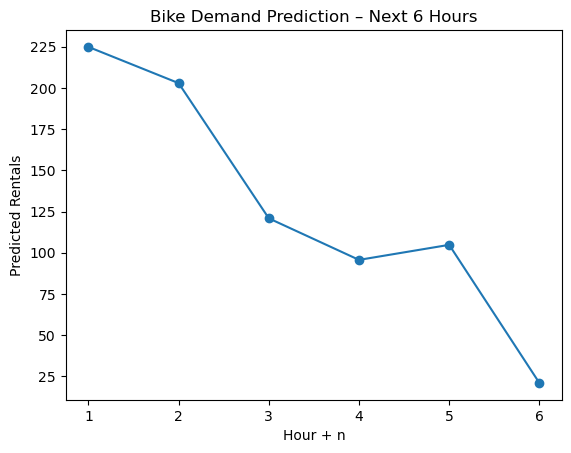

In [64]:
plt.figure()
plt.plot(range(1,7), future_hours, marker='o')
plt.title("Bike Demand Prediction – Next 6 Hours")
plt.xlabel("Hour + n")
plt.ylabel("Predicted Rentals")
plt.show()


In [74]:

future_days = []
X_curr_day = X_test_day.iloc[-1:].copy()

print("Daily Bike Demand Forecast:")

for i in range(6):
    pred = float(best_rf_day.predict(X_curr_day)[0])
    pred = round(pred, 2)
    future_days.append(pred)

    print(f"Day+{i+1} = {pred}")

    

Daily Bike Demand Forecast:
Day+1 = 5592.25
Day+2 = 5592.25
Day+3 = 5592.25
Day+4 = 5592.25
Day+5 = 5592.25
Day+6 = 5592.25


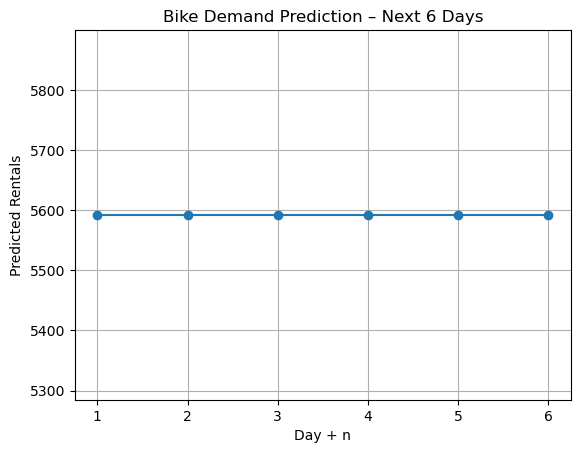

In [69]:
plt.figure()
plt.plot(range(1, 7), future_days, marker='o')
plt.title("Bike Demand Prediction – Next 6 Days")
plt.xlabel("Day + n")
plt.ylabel("Predicted Rentals")
plt.xticks(range(1, 7))
plt.grid(True)
plt.show()
